In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=7,3
sns.set_theme(style="whitegrid", palette="dark")

In [2]:
coffee=pd.read_excel(r'C:\Users\admin\Downloads\archive\Coffee Shop Sales.xlsx')

In [3]:
coffee

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [4]:
coffee.shape

(149116, 11)

In [5]:
coffee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [6]:
coffee.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [7]:
coffee.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [8]:
coffee.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [9]:
coffee.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
transaction_id,149116.0,74737.371872,1.0,37335.75,74727.5,112094.25,149456.0,43153.600016
transaction_date,149116,2023-04-15 11:50:32.173609984,2023-01-01 00:00:00,2023-03-06 00:00:00,2023-04-24 00:00:00,2023-05-30 00:00:00,2023-06-30 00:00:00,NaN
transaction_qty,149116.0,1.438276,1.0,1.0,1.0,2.0,8.0,0.542509
store_id,149116.0,5.342063,3.0,3.0,5.0,8.0,8.0,2.074241
product_id,149116.0,47.918607,1.0,33.0,47.0,60.0,87.0,17.93002
unit_price,149116.0,3.382219,0.8,2.5,3.0,3.75,45.0,2.658723


In [10]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<Axes: xlabel='transaction_qty', ylabel='Density'>

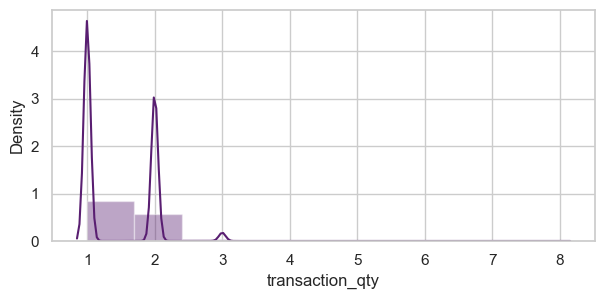

In [11]:
sns.distplot(coffee.transaction_qty,color='m',bins=10)

<Axes: xlabel='store_id', ylabel='Density'>

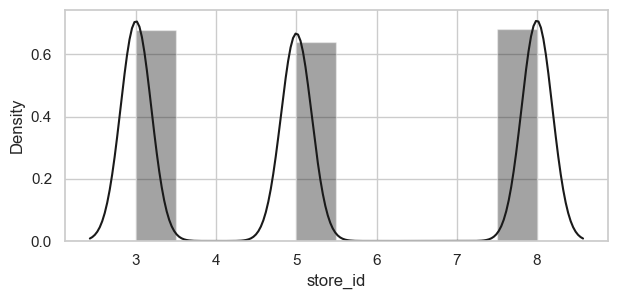

In [12]:
sns.distplot(coffee.store_id,color='k',bins=10)

<Axes: xlabel='product_id', ylabel='Density'>

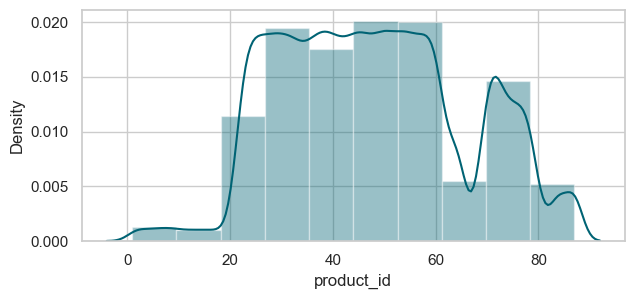

In [13]:
sns.distplot(coffee.product_id,color='c',bins=10)

<Axes: xlabel='unit_price', ylabel='Density'>

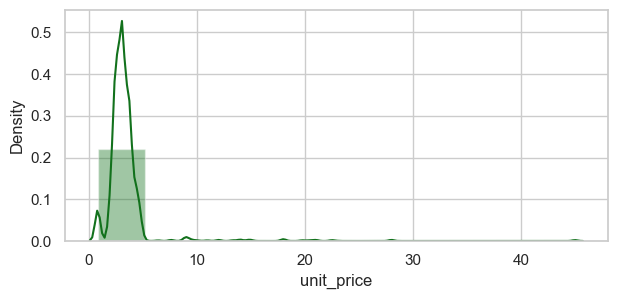

In [14]:
sns.distplot(coffee.unit_price,color='g',bins=10)

In [15]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<Axes: xlabel='transaction_qty', ylabel='count'>

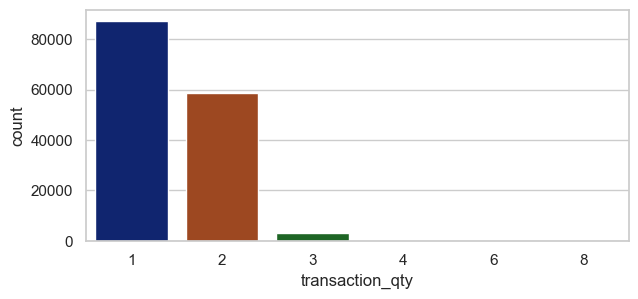

In [16]:
sns.countplot(data=coffee,x='transaction_qty',palette='dark')

<Axes: xlabel='store_id', ylabel='count'>

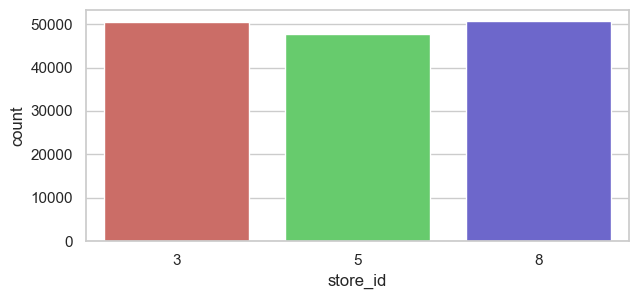

In [17]:
sns.countplot(data=coffee,x='store_id',palette='hls')

<Axes: xlabel='store_location', ylabel='count'>

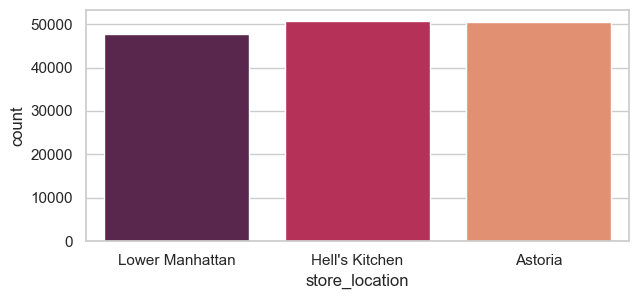

In [18]:
sns.countplot(data=coffee,x='store_location',palette='rocket')

<Axes: xlabel='product_category', ylabel='count'>

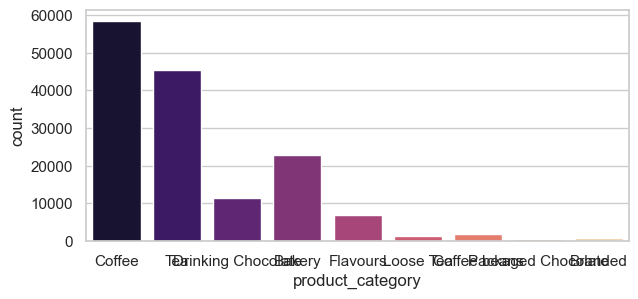

In [19]:
sns.countplot(data=coffee,x='product_category',palette='magma')

In [20]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<Axes: xlabel='transaction_qty', ylabel='count'>

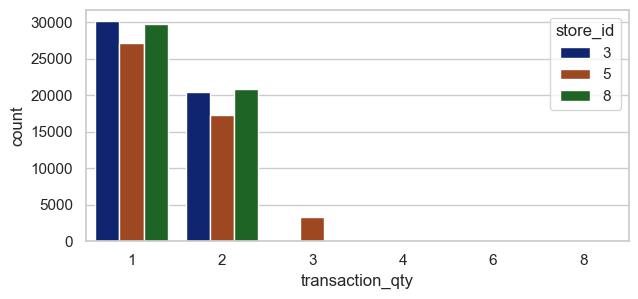

In [21]:
sns.countplot(data=coffee,x='transaction_qty',hue='store_id',palette='dark')

<Axes: xlabel='store_id', ylabel='count'>

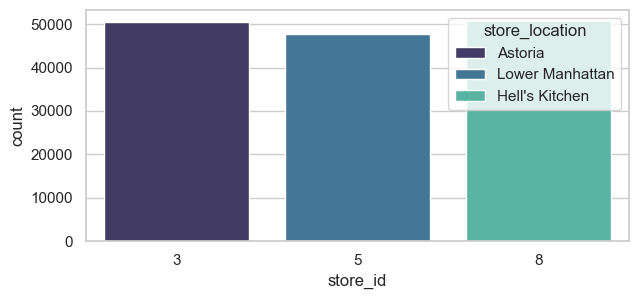

In [22]:
sns.countplot(data=coffee,x='store_id',hue='store_location',palette='mako')

<Axes: xlabel='product_category', ylabel='count'>

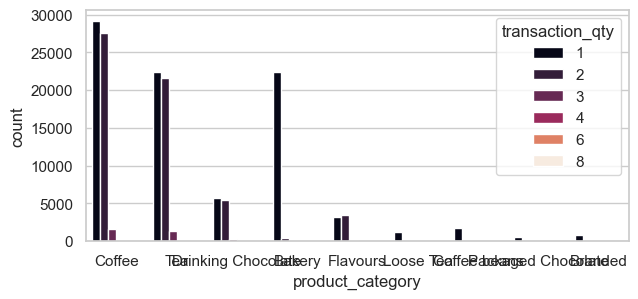

In [23]:
sns.countplot(data=coffee,x='product_category',hue='transaction_qty',palette='rocket')

<Axes: xlabel='store_location', ylabel='count'>

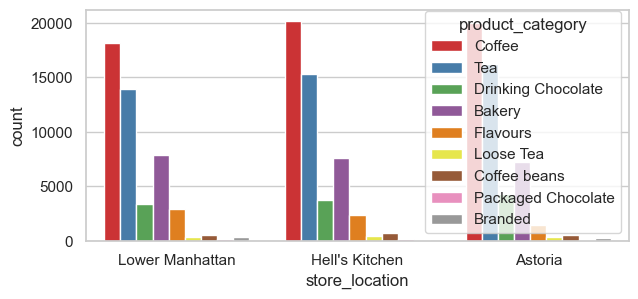

In [24]:
sns.countplot(data=coffee,x='store_location',hue='product_category',palette='Set1')

<Axes: xlabel='store_location', ylabel='count'>

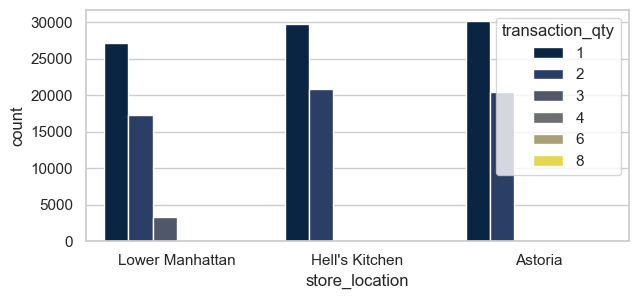

In [25]:
sns.countplot(data=coffee,x='store_location',hue='transaction_qty',palette='cividis')

In [26]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


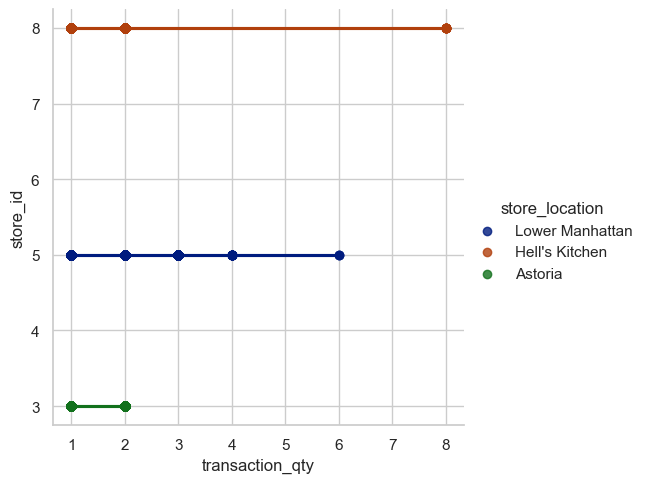

In [27]:
sns.lmplot(data=coffee,x='transaction_qty',y='store_id',palette='dark',hue='store_location')

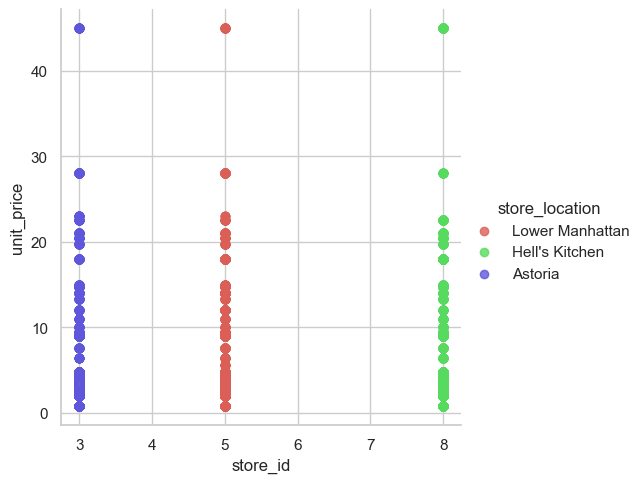

In [28]:
sns.lmplot(data=coffee,x='store_id',y='unit_price',palette='hls',hue='store_location')

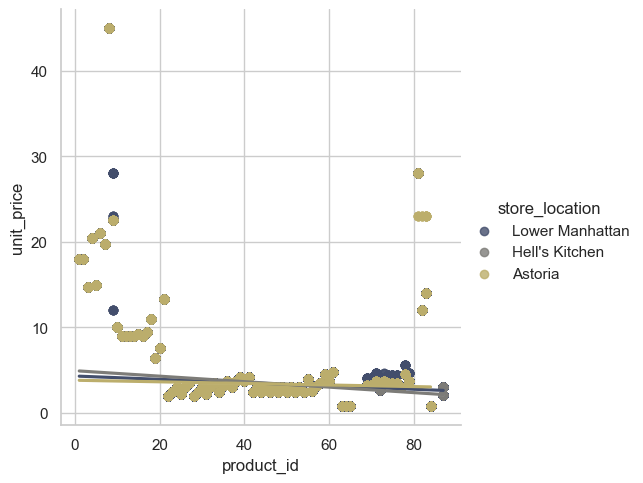

In [29]:
sns.lmplot(data=coffee,x='product_id',y='unit_price',palette='cividis',hue='store_location')

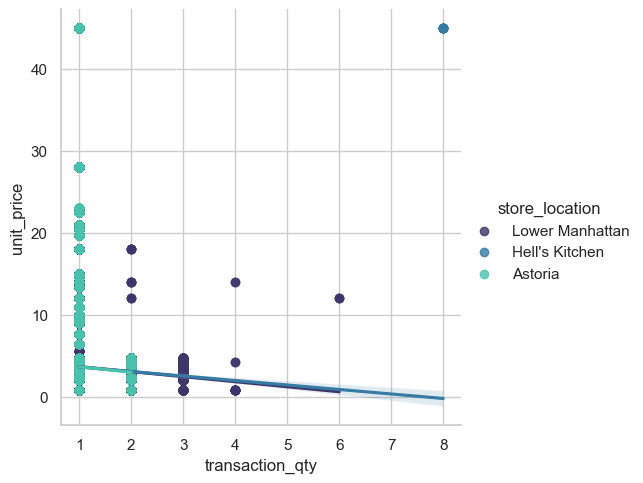

In [30]:
sns.lmplot(data=coffee,x='transaction_qty',y='unit_price',palette='mako',hue='store_location')

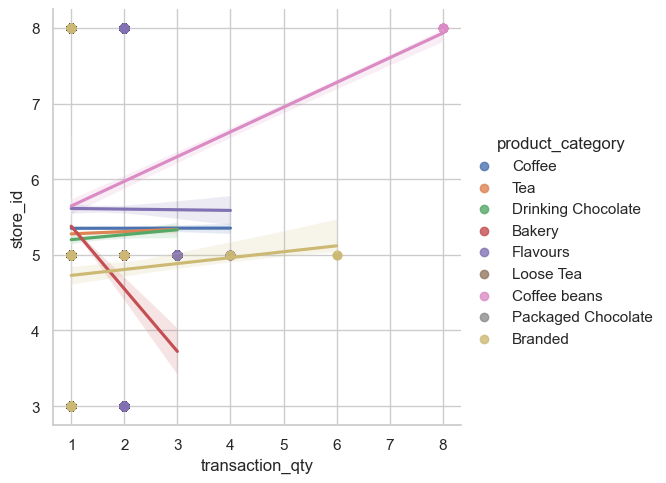

In [31]:
sns.lmplot(data=coffee,x='transaction_qty',y='store_id',palette='deep',hue='product_category')

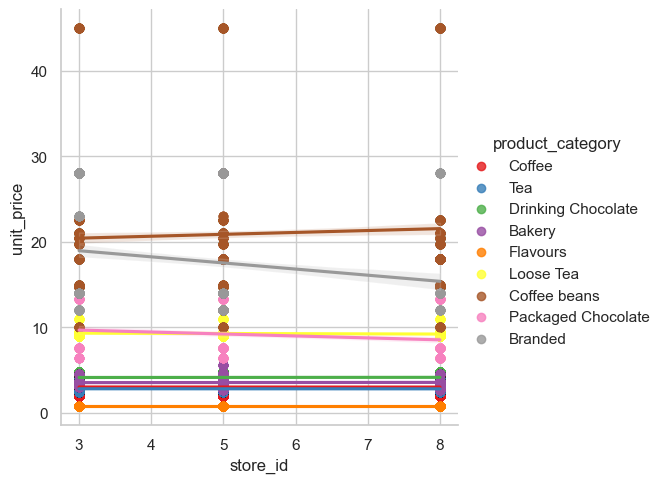

In [32]:
sns.lmplot(data=coffee,x='store_id',y='unit_price',palette='Set1',hue='product_category')

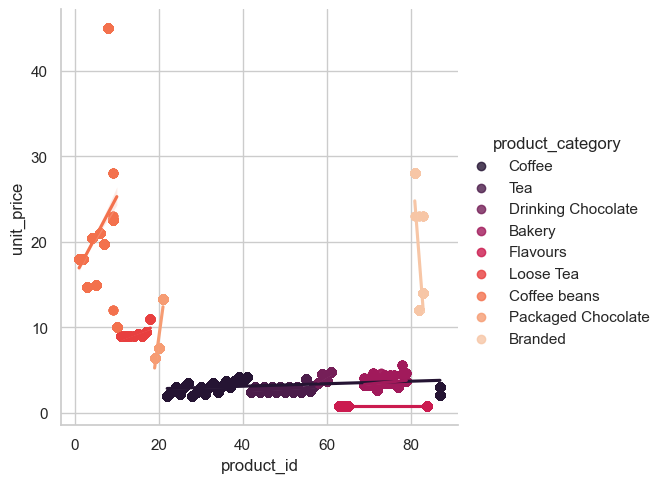

In [33]:
sns.lmplot(data=coffee,x='product_id',y='unit_price',palette='rocket',hue='product_category')

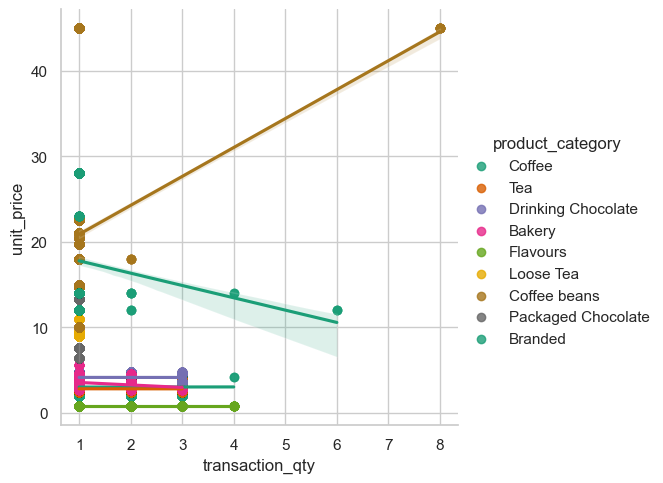

In [34]:
sns.lmplot(data=coffee,x='transaction_qty',y='unit_price',palette='Dark2',hue='product_category')

In [35]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<Axes: xlabel='product_category', ylabel='transaction_qty'>

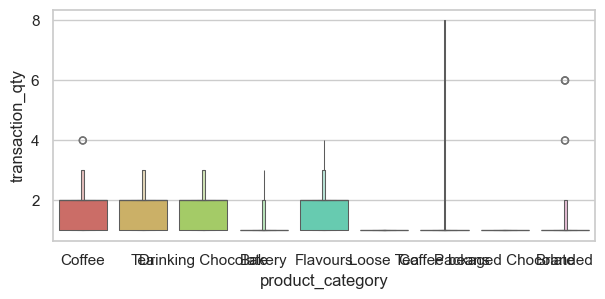

In [36]:
sns.boxenplot(data=coffee,x='product_category',y='transaction_qty',palette='hls')

<Axes: xlabel='product_category', ylabel='product_id'>

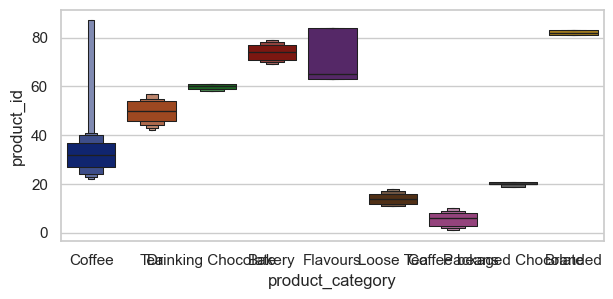

In [37]:
sns.boxenplot(data=coffee,x='product_category',y='product_id',palette='dark')

<Axes: xlabel='product_category', ylabel='product_id'>

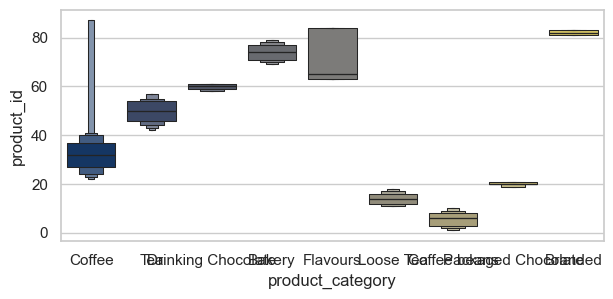

In [38]:
sns.boxenplot(data=coffee,x='product_category',y='product_id',palette='cividis')

<Axes: xlabel='product_category', ylabel='unit_price'>

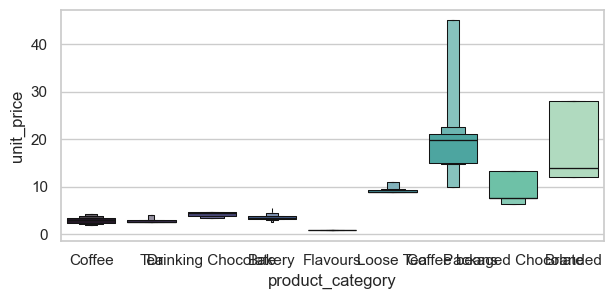

In [39]:
sns.boxenplot(data=coffee,x='product_category',y='unit_price',palette='mako')

<Axes: xlabel='store_location', ylabel='transaction_qty'>

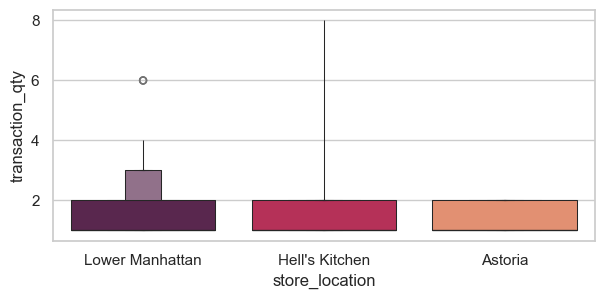

In [40]:
sns.boxenplot(data=coffee,x='store_location',y='transaction_qty',palette='rocket')

<Axes: xlabel='product_category', ylabel='store_id'>

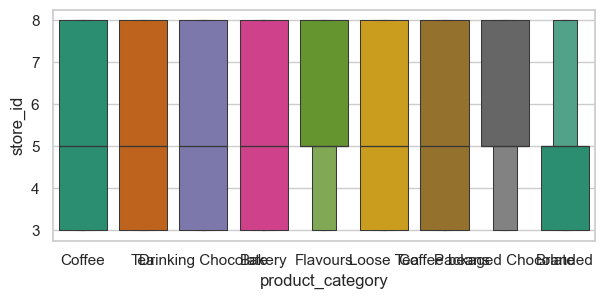

In [41]:
sns.boxenplot(data=coffee,x='product_category',y='store_id',palette='Dark2')

<Axes: xlabel='store_location', ylabel='unit_price'>

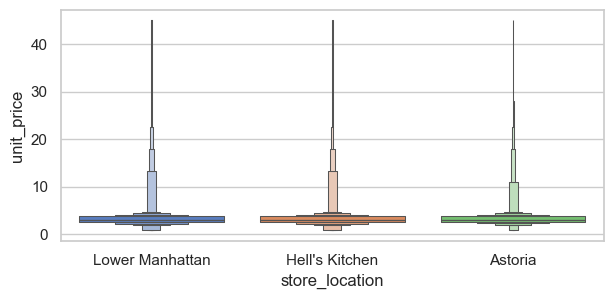

In [42]:
sns.boxenplot(data=coffee,x='store_location',y='unit_price',palette='muted')

In [43]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


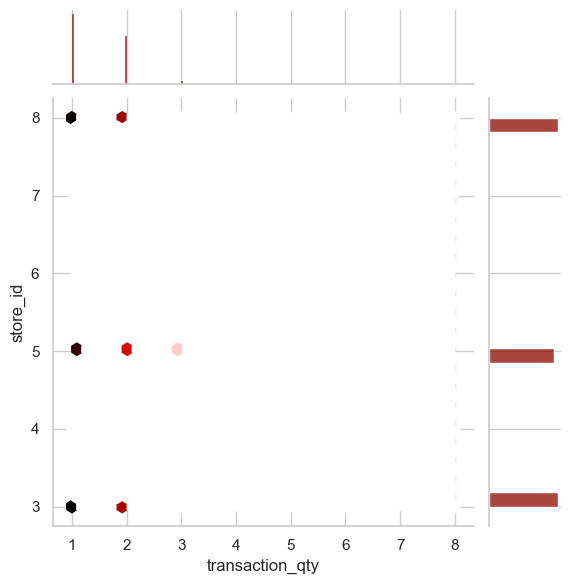

In [44]:
sns.jointplot(data=coffee,x='transaction_qty',y='store_id',color='r',kind='hex')

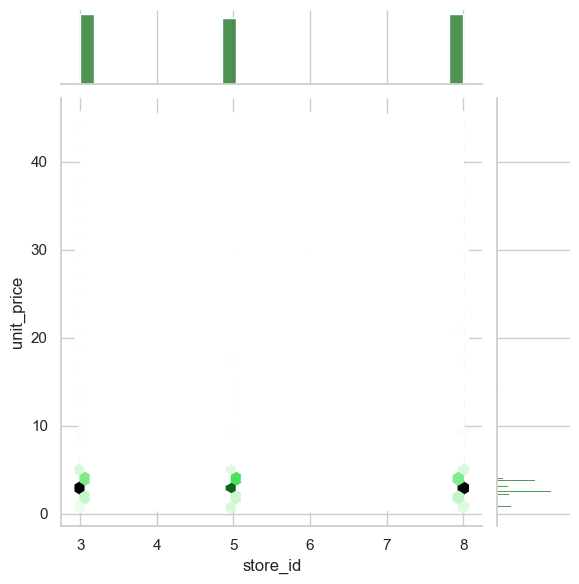

In [45]:
sns.jointplot(data=coffee,x='store_id',y='unit_price',color='g',kind='hex')

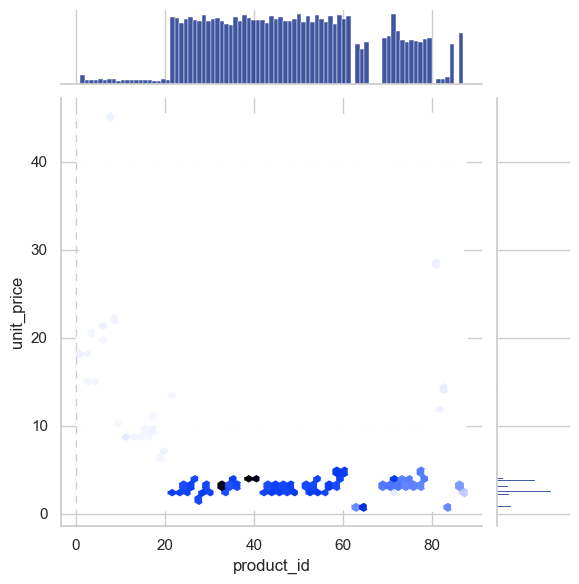

In [46]:
sns.jointplot(data=coffee,x='product_id',y='unit_price',color='b',kind='hex')

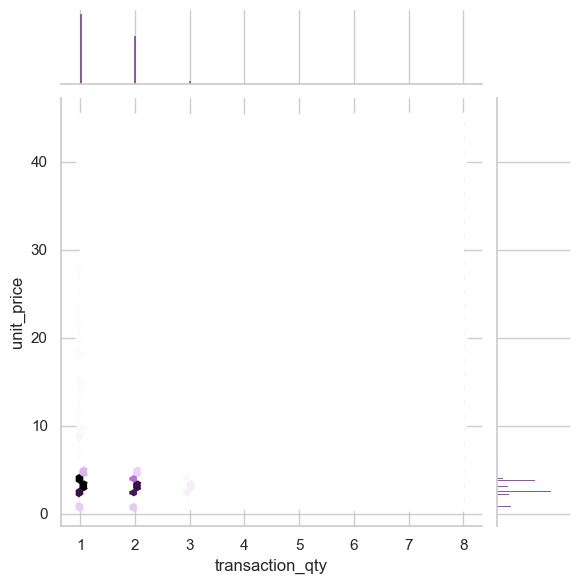

In [47]:
sns.jointplot(data=coffee,x='transaction_qty',y='unit_price',color='m',kind='hex')

In [48]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<Axes: xlabel='store_location', ylabel='transaction_qty'>

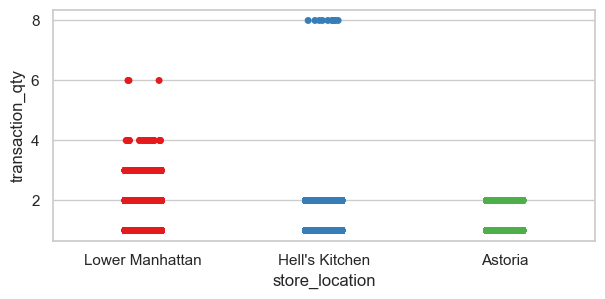

In [49]:
sns.stripplot(data=coffee,x='store_location',y='transaction_qty',palette='Set1')

<Axes: xlabel='store_location', ylabel='store_id'>

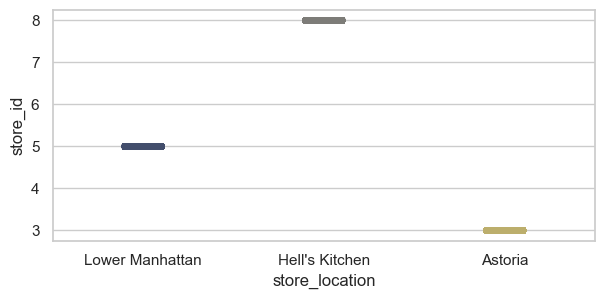

In [50]:
sns.stripplot(data=coffee,x='store_location',y='store_id',palette='cividis')

<Axes: xlabel='store_location', ylabel='product_id'>

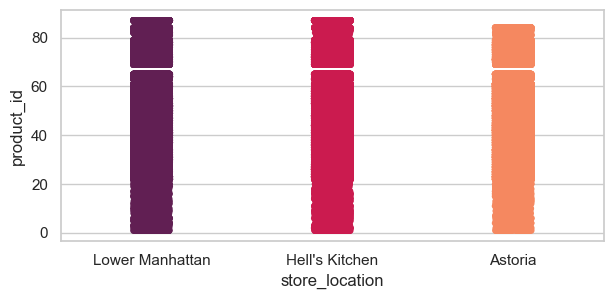

In [51]:
sns.stripplot(data=coffee,x='store_location',y='product_id',palette='rocket')

<Axes: xlabel='store_location', ylabel='unit_price'>

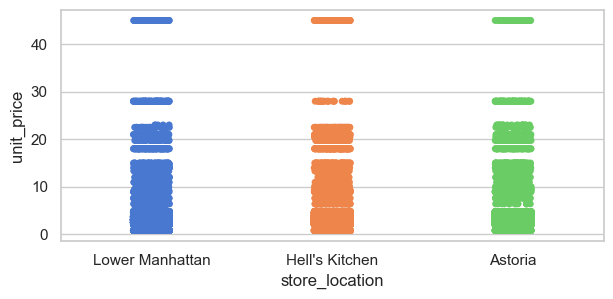

In [52]:
sns.stripplot(data=coffee,x='store_location',y='unit_price',palette='muted')

<Axes: xlabel='product_category', ylabel='store_id'>

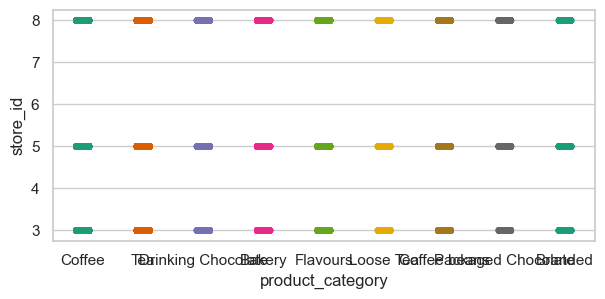

In [53]:
sns.stripplot(data=coffee,x='product_category',y='store_id',palette='Dark2')

<Axes: xlabel='product_category', ylabel='transaction_qty'>

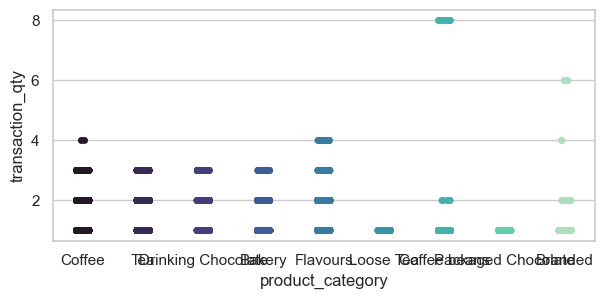

In [54]:
sns.stripplot(data=coffee,x='product_category',y='transaction_qty',palette='mako')

<Axes: xlabel='product_category', ylabel='unit_price'>

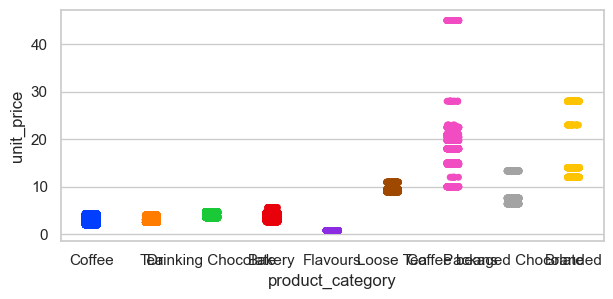

In [55]:
sns.stripplot(data=coffee,x='product_category',y='unit_price',palette='bright')

<Axes: xlabel='product_category', ylabel='product_id'>

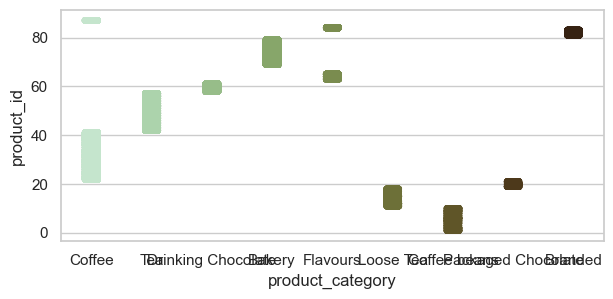

In [56]:
sns.stripplot(data=coffee,x='product_category',y='product_id',palette='ch:34')

In [57]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


<Axes: xlabel='transaction_qty', ylabel='Density'>

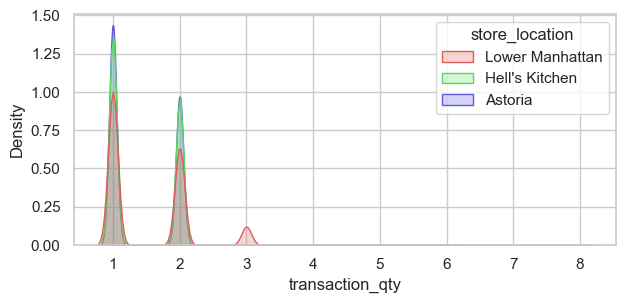

In [58]:
sns.kdeplot(data=coffee,x='transaction_qty',hue='store_location',palette='hls',fill=True)

<Axes: xlabel='product_id', ylabel='Density'>

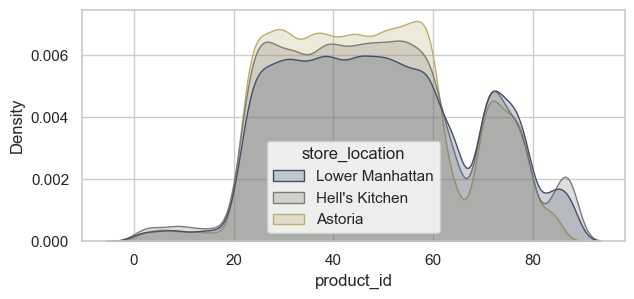

In [59]:
sns.kdeplot(data=coffee,x='product_id',hue='store_location',palette='cividis',fill=True)

<Axes: xlabel='unit_price', ylabel='Density'>

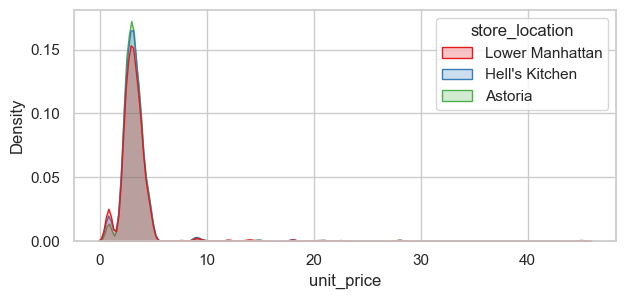

In [60]:
sns.kdeplot(data=coffee,x='unit_price',hue='store_location',palette='Set1',fill=True)

<Axes: xlabel='transaction_qty', ylabel='Density'>

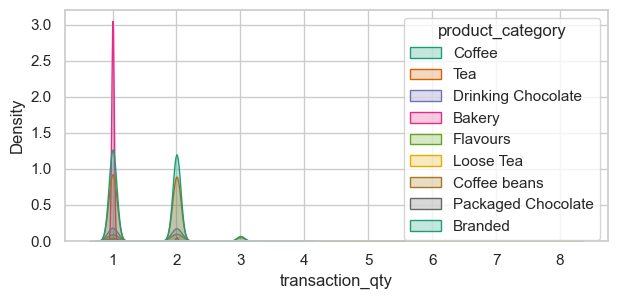

In [61]:
sns.kdeplot(data=coffee,x='transaction_qty',hue='product_category',palette='Dark2',fill=True)

<Axes: xlabel='store_id', ylabel='Density'>

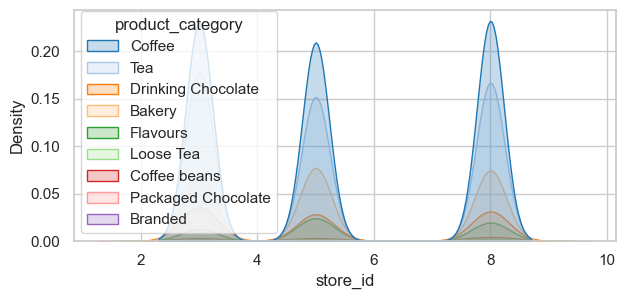

In [62]:
sns.kdeplot(data=coffee,x='store_id',hue='product_category',palette='tab20',fill=True)

<Axes: xlabel='product_id', ylabel='Density'>

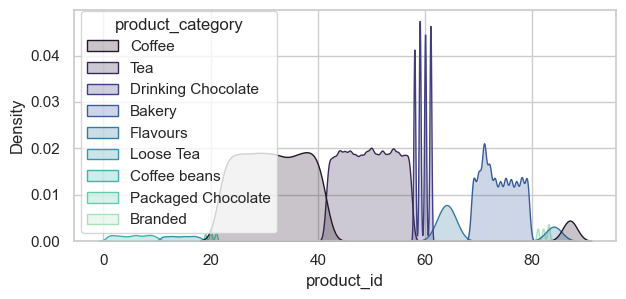

In [63]:
sns.kdeplot(data=coffee,x='product_id',hue='product_category',palette='mako',fill=True)

<Axes: xlabel='unit_price', ylabel='Density'>

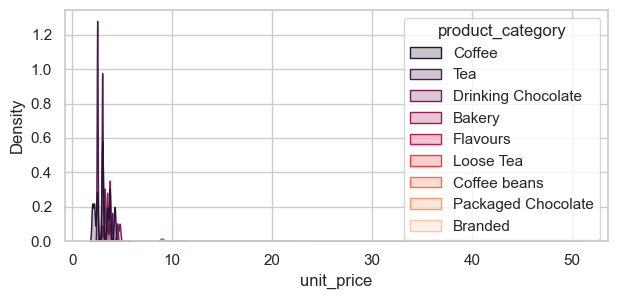

In [64]:
sns.kdeplot(data=coffee,x='unit_price',hue='product_category',palette='rocket',fill=True)

In [65]:
coffee.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


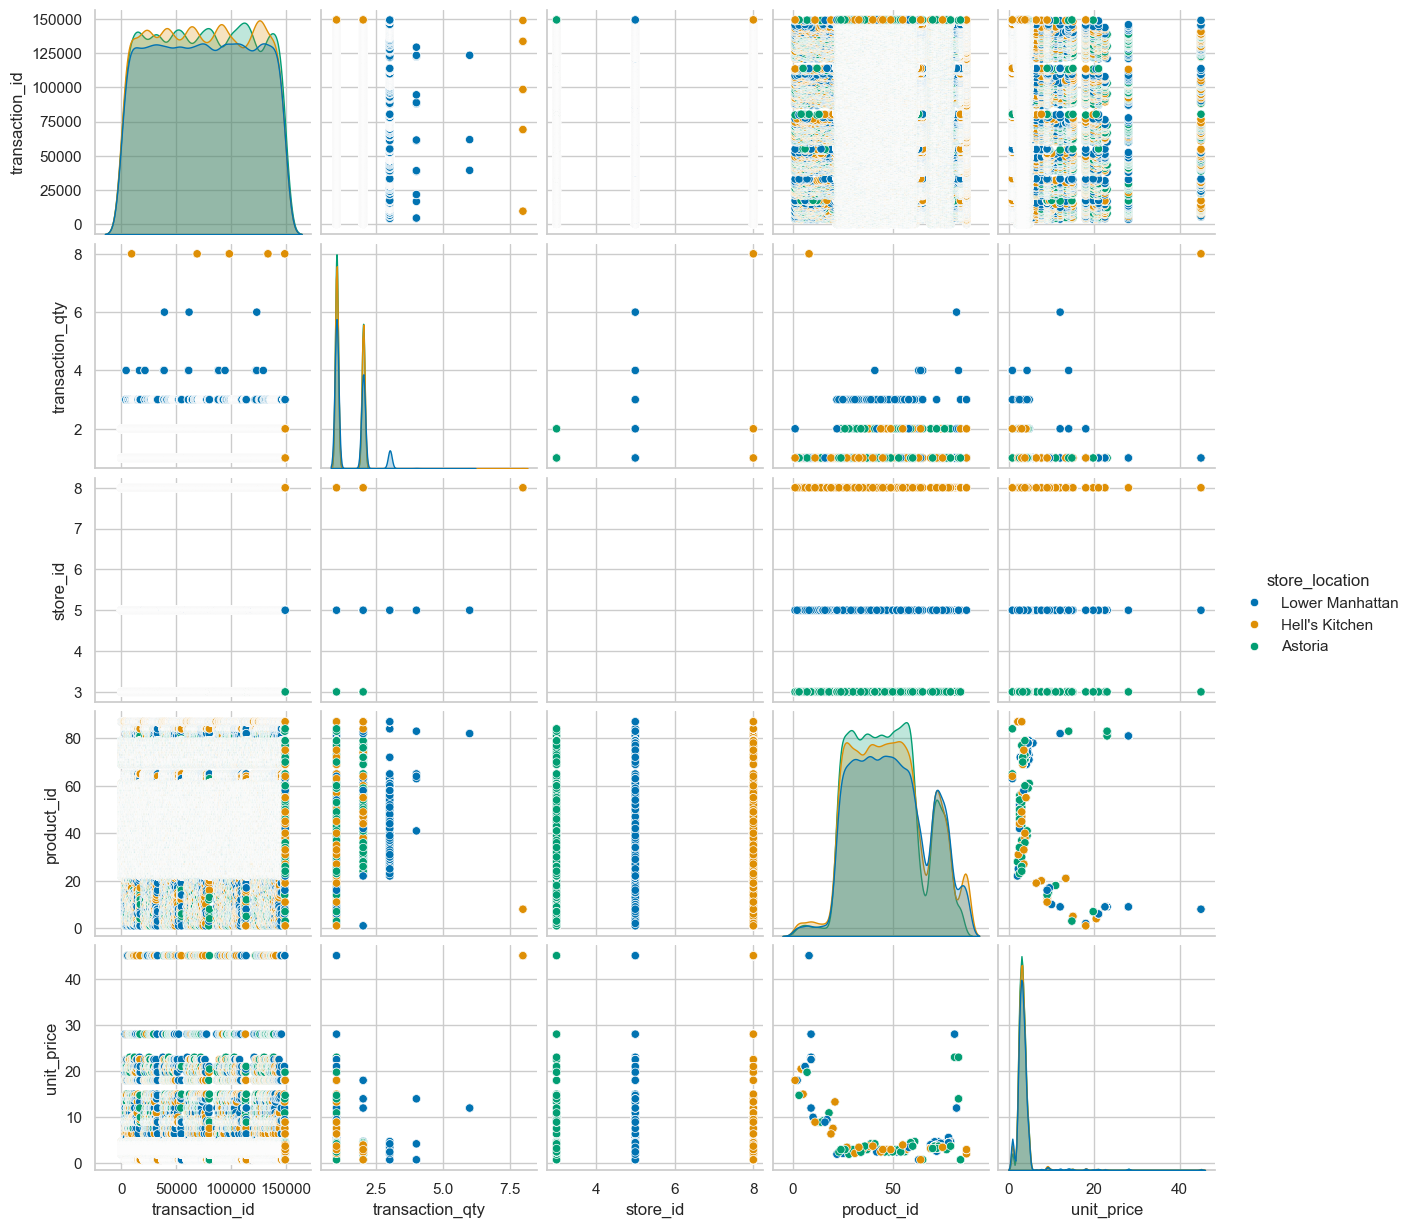

In [66]:
sns.pairplot(coffee, hue="store_location",palette='colorblind')

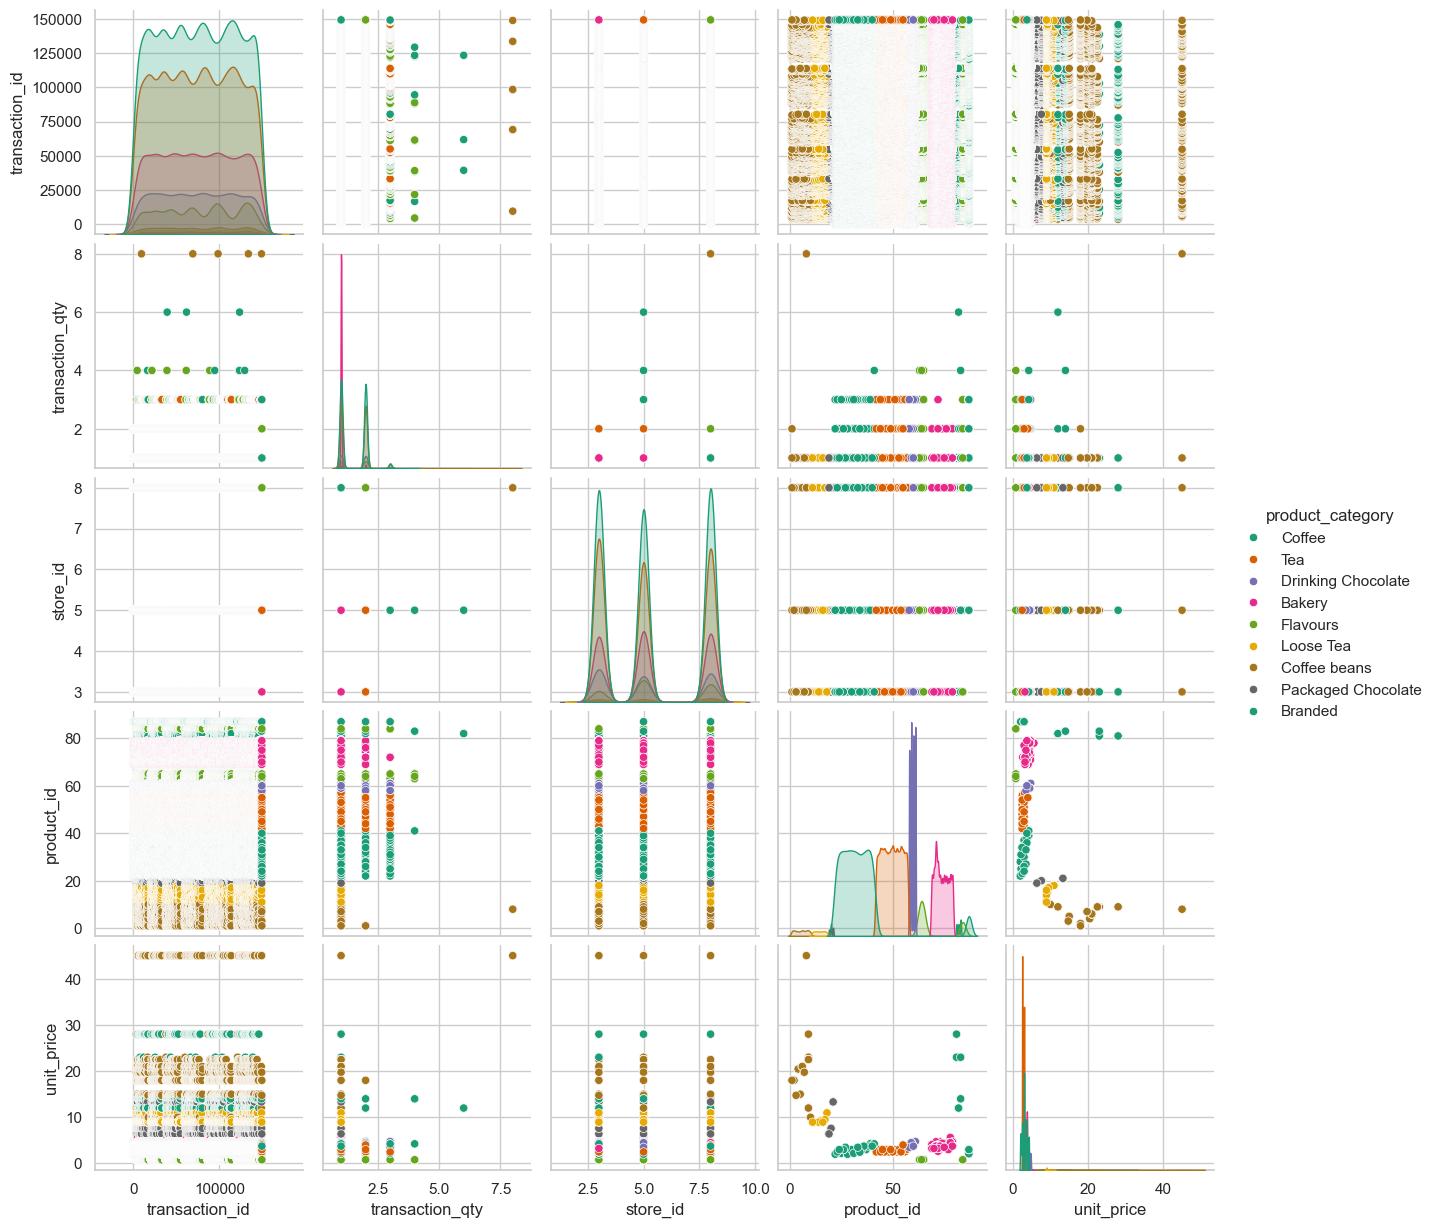

In [67]:
sns.pairplot(coffee, hue="product_category",palette='Dark2')